### 1. Import packages

In [11]:
import os, sys, time, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

from art.estimators.classification import PyTorchClassifier
from art_generator import (
    FGSMAttackGenerator,
    PGDAttackGenerator,
    CWAttackGenerator,
    DeepFoolAttackGenerator,
    ZooAttackGenerator,
    HSJAAttackGenerator,
    JSMAAttackGenerator,
    MIMAttackGenerator,
)
from utils.masking import get_mutate_indices
from utils.paths import load_attack_config, load_adv_training_config

### 2. Model architecture & Scaled wrapper

In [12]:
class _AttnPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.proj = nn.Linear(d, 1)
    def forward(self, H):
        w = torch.softmax(self.proj(H).squeeze(-1), dim=1)
        return (H * w.unsqueeze(-1)).sum(1)

class _LSTMTabular(nn.Module):
    def __init__(self, step_dim, hidden=256, layers=2, n_classes=12, dropout=0.15, bidir=True):
        super().__init__()
        self.step_dim = step_dim
        self.in_norm = nn.LayerNorm(step_dim)
        self.lstm = nn.LSTM(
            input_size=step_dim, hidden_size=hidden, num_layers=layers,
            batch_first=True, dropout=dropout if layers > 1 else 0.0, bidirectional=bidir,
        )
        d_out = hidden * (2 if bidir else 1)
        self.pool = _AttnPool(d_out)
        self.head = nn.Sequential(
            nn.Linear(d_out, d_out // 2), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(d_out // 2, n_classes),
        )
    def forward(self, x):
        B, F = x.shape
        S = int(math.ceil(F / self.step_dim))
        pad = S * self.step_dim - F
        if pad > 0:
            x = nn.functional.pad(x, (0, pad))
        x = self.in_norm(x.view(B, S, self.step_dim))
        H, _ = self.lstm(x)
        return self.head(self.pool(H))

class _ScaledLSTM(nn.Module):
    """Wraps _LSTMTabular with embedded StandardScaler so ART operates in raw feature space."""
    def __init__(self, lstm, mean, scale):
        super().__init__()
        self.lstm = lstm
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        x_scaled = (x - self.mean_) / self.scale_
        return self.lstm(x_scaled)

### 3. Load model and test data

In [13]:
DEVICE = 'cpu'  # change to 'cuda' if GPU available

# Load test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values.astype(np.float32)
y_test = df_test['Label'].values.astype(int)
feature_names = df_test.columns[:-1].tolist()

# Metadata for art_generator
input_metadata = {'feature_names': feature_names, 'label_column': 'Label'}

# Masking: protect binary/categorical features
mutate_indices = get_mutate_indices(df_test)
print(f'Protected features (binary/categorical): {len(mutate_indices)} indices')

# Load LSTM checkpoint
ckpt = torch.load('../../training/models/framework_lstm_TVAE.pth', map_location=DEVICE, weights_only=False)

lstm_net = _LSTMTabular(
    step_dim=int(ckpt['step_dim']), hidden=int(ckpt['hidden']),
    layers=int(ckpt['layers']), n_classes=int(ckpt['num_classes']),
    dropout=float(ckpt['dropout']), bidir=bool(ckpt['bidir']),
)
lstm_net.load_state_dict(ckpt['state_dict'])
lstm_net.eval()

scaled_model = _ScaledLSTM(lstm_net, ckpt['scaler'].mean_, ckpt['scaler'].scale_).to(DEVICE)
scaled_model.eval()

num_classes = int(ckpt['num_classes'])
input_dim = int(ckpt['scaler'].mean_.shape[0])

Protected features (binary/categorical): 12 indices


In [14]:
# Create ART classifier
classifier = PyTorchClassifier(
    model=scaled_model,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)

predictions = classifier.predict(X_test)
original_preds = np.argmax(predictions, axis=1)
accuracy = accuracy_score(y_test, original_preds)
print(f'Original Accuracy: {accuracy * 100:.2f}%')

Original Accuracy: 68.10%


In [15]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100

    print(f'--- {attack_name} ---')
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Precision: {precision:.2f}%')
    print(f'Recall: {recall:.2f}%')
    print(f'F1 Score: {f1:.4f}')

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'LSTM {attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

### 4. Evaluate original model on adversarial test samples

--- FGSM (before AT) ---
Accuracy: 40.19%
Precision: 43.81%
Recall: 40.19%
F1 Score: 0.3839


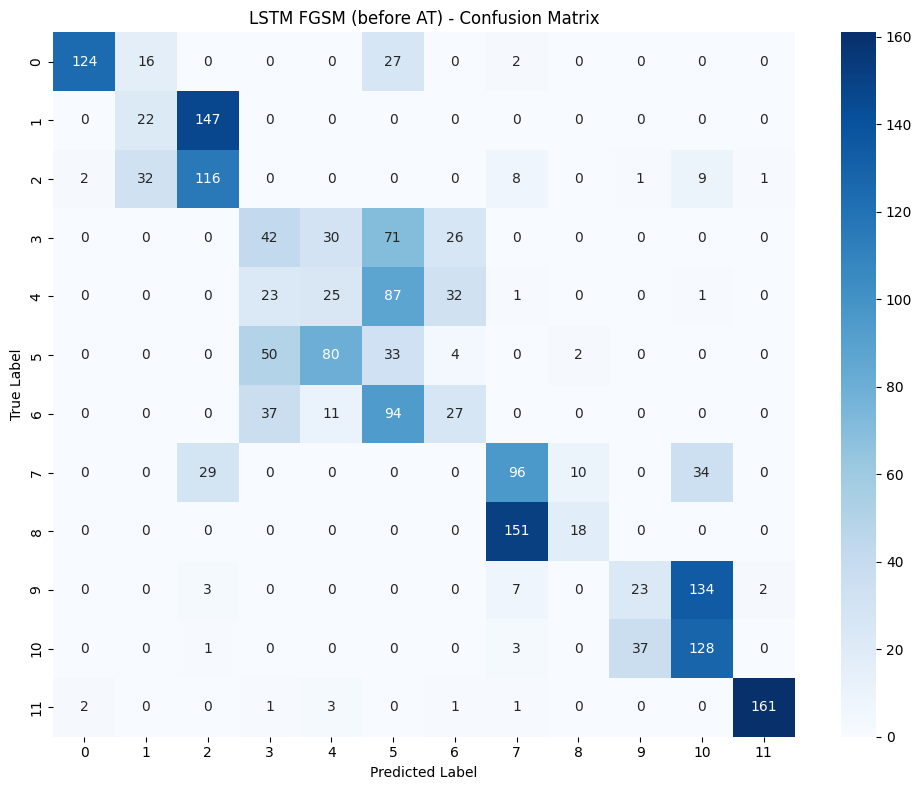

--- PGD (before AT) ---
Accuracy: 22.93%
Precision: 26.71%
Recall: 22.93%
F1 Score: 0.2232


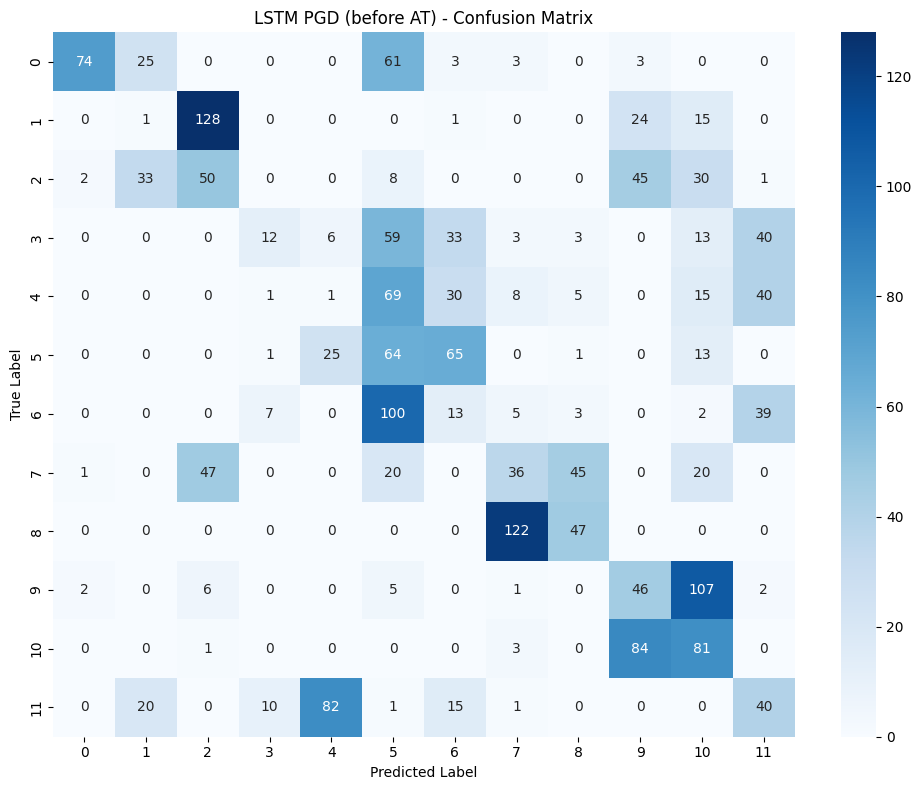

--- DEEPFOOL (before AT) ---
Accuracy: 12.48%
Precision: 12.87%
Recall: 12.48%
F1 Score: 0.1179


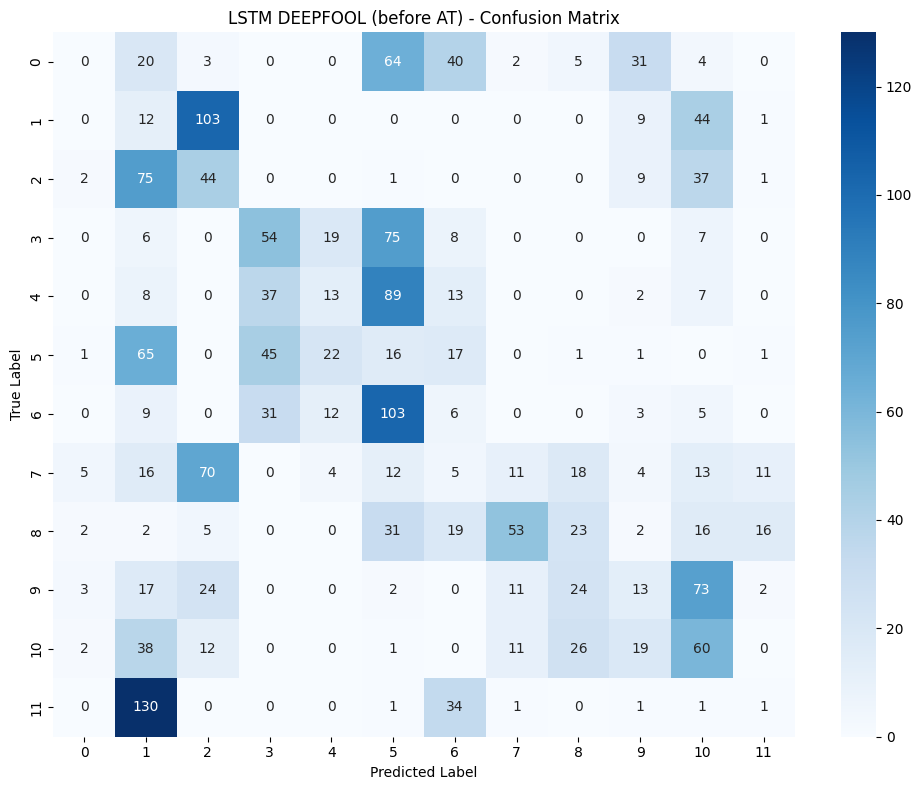

--- CW (before AT) ---
Accuracy: 42.55%
Precision: 44.21%
Recall: 42.55%
F1 Score: 0.3886


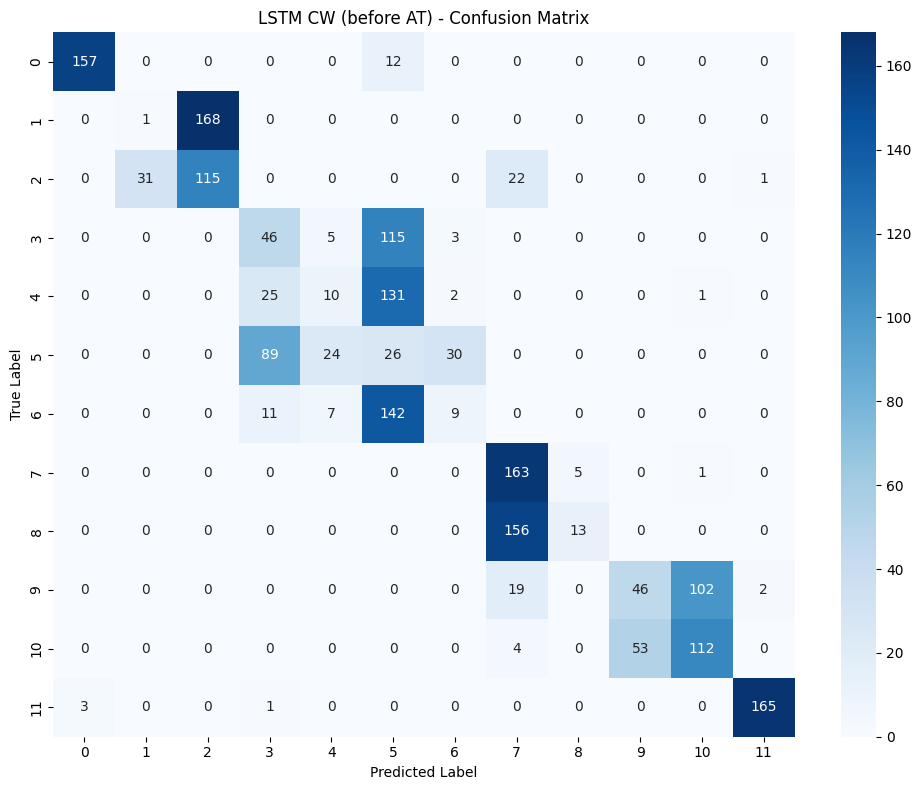

--- JSMA (before AT) ---
Accuracy: 13.56%
Precision: 20.02%
Recall: 13.56%
F1 Score: 0.1123


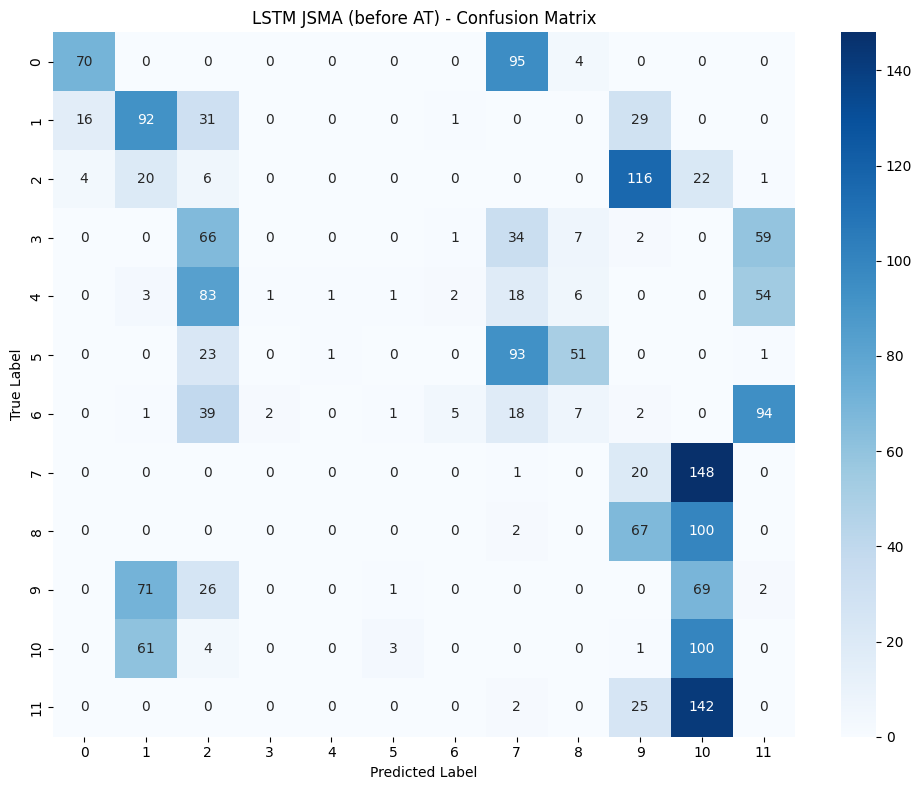

--- ZOO (before AT) ---
Accuracy: 25.89%
Precision: 33.32%
Recall: 25.89%
F1 Score: 0.2603


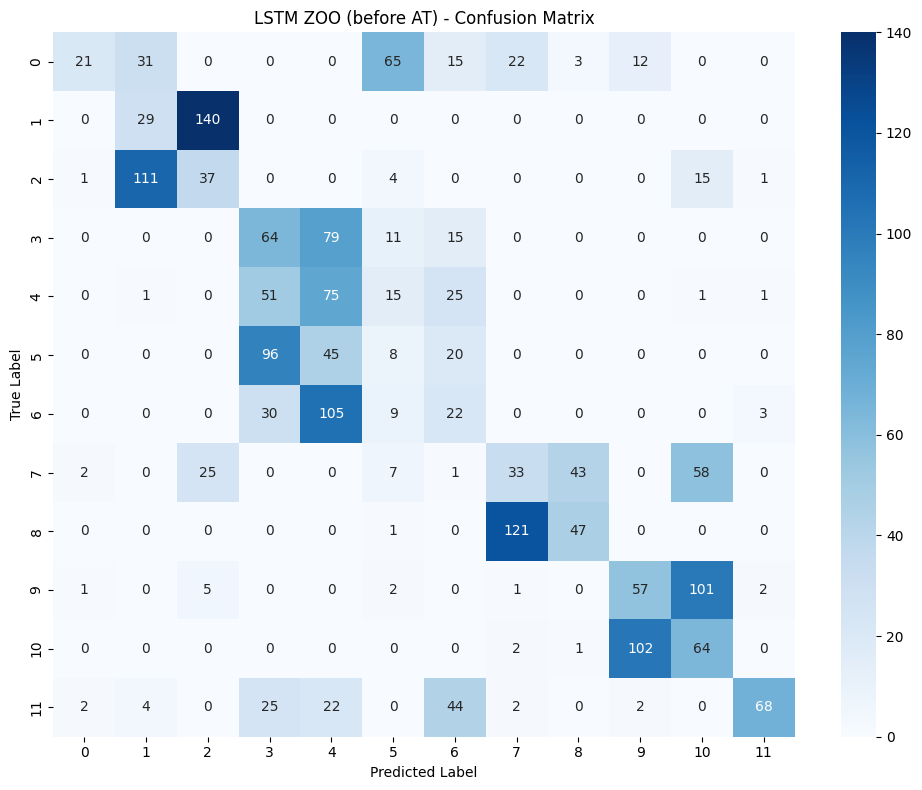

--- HSJA (before AT) ---
Accuracy: 10.26%
Precision: 13.31%
Recall: 10.26%
F1 Score: 0.0952


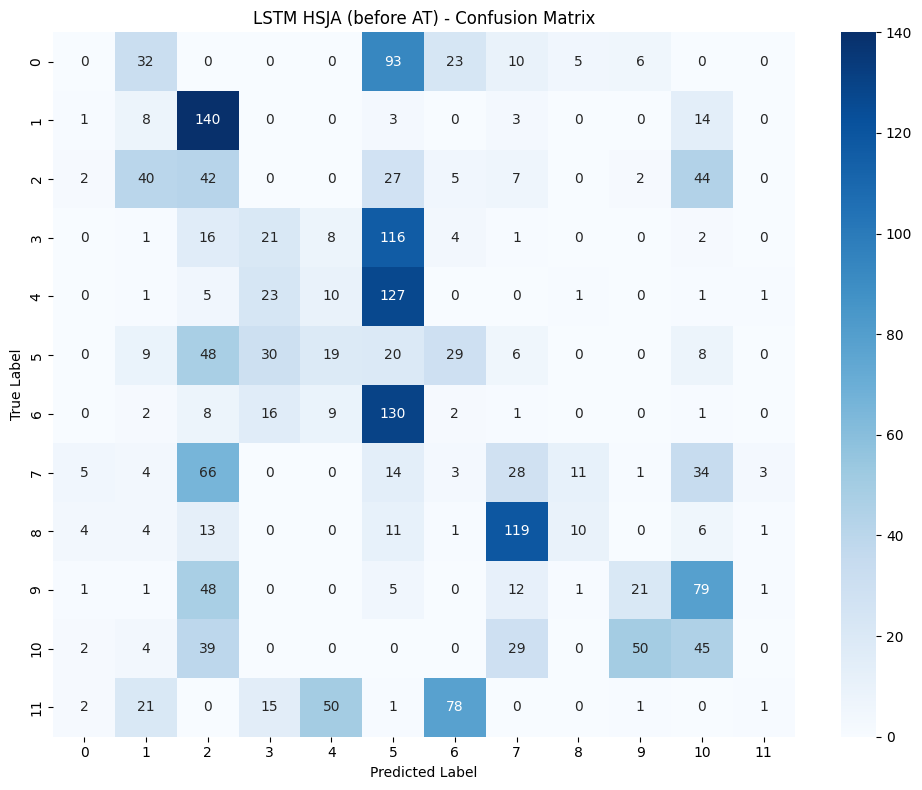

In [16]:
ADV_EVAL_DIR = '../../adv_samples/adv_eval/lstm'

attack_names = ['fgsm', 'pgd', 'deepfool', 'cw', 'jsma', 'zoo', 'hsja']
adv_eval_data = {}

for atk in attack_names:
    path = os.path.join(ADV_EVAL_DIR, f'lstm_{atk}_adv.csv')
    if os.path.exists(path):
        df_adv = pd.read_csv(path)
        adv_eval_data[atk] = df_adv.drop(columns=['Label']).values.astype(np.float32)
        preds_adv = classifier.predict(adv_eval_data[atk])
        evaluate_attack(y_test, preds_adv, f'{atk.upper()} (before AT)')
    else:
        print(f'[SKIP] {path} not found')

### 5. Generate adversarial samples from training data

In [17]:
# Load training data
df_train = pd.read_csv('../../datasets/augment/train_tvae_9600.csv')
X_train = df_train.drop(columns=['Label']).values.astype(np.float32)
y_train = df_train['Label'].values.astype(int)

ADV_TRAIN_DIR = '../../adv_samples/adv_training/lstm'
os.makedirs(ADV_TRAIN_DIR, exist_ok=True)

print(f'Train set: {X_train.shape}')

Train set: (9600, 66)


#### FGSM on train data

In [18]:
cfg = load_adv_training_config('fgsm')
gen = FGSMAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_fgsm_train_adv.csv'), index=False)

Runtime: 3.19s


#### PGD on train data

In [19]:
cfg = load_adv_training_config('pgd')
gen = PGDAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_pgd_train_adv.csv'), index=False)

Runtime: 508.56s


#### DeepFool on train data

In [20]:
cfg = load_adv_training_config('deepfool')
gen = DeepFoolAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_deepfool_train_adv.csv'), index=False)

DeepFool: 100%|██████████| 150/150 [06:34<00:00,  2.63s/it]


Runtime: 406.74s


#### ZOO on train data

In [ ]:
cfg = load_attack_config('zoo')  # black-box: no AT-specific config
gen = ZooAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_zoo_train_adv.csv'), index=False)

In [ ]:
cfg = load_adv_training_config('jsma')
gen = JSMAAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_jsma_train_adv.csv'), index=False)

#### CW on train data

In [21]:
cfg = load_adv_training_config('cw')
gen = CWAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_cw_train_adv.csv'), index=False)

KeyboardInterrupt: 

#### HSJA on train data

In [ ]:
cfg = load_attack_config('hsja')  # black-box: no AT-specific config
gen = HSJAAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_hsja_train_adv.csv'), index=False)

#### MIM on train data

In [22]:
cfg = load_adv_training_config('mim')
gen = MIMAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_mim_train_adv.csv'), index=False)

Runtime: 169.88s


### 6. Adversarial training — retrain LSTM

In [ ]:
# Load all adversarial training samples
at_attacks = ['fgsm', 'pgd', 'deepfool', 'cw', 'jsma', 'zoo', 'hsja', 'mim']

adv_parts = []
for atk in at_attacks:
    path = os.path.join(ADV_TRAIN_DIR, f'lstm_{atk}_train_adv.csv')
    if os.path.exists(path):
        df_at = pd.read_csv(path)
        adv_parts.append(df_at.drop(columns=['Label']).values.astype(np.float32))
        print(f'Loaded {atk}: {adv_parts[-1].shape}')
    else:
        print(f'[SKIP] {path} not found')

# Merge: original train + all adversarial
adv_all = np.concatenate(adv_parts, axis=0)
X_train_at = np.concatenate([X_train, adv_all], axis=0)
y_train_at = np.concatenate([y_train] + [y_train] * len(adv_parts), axis=0)

print(f'\nAT train data: {X_train_at.shape}')
print(f'AT train labels: {y_train_at.shape}')

In [ ]:
# Retrain LSTM from scratch with adversarial data
scaler_at = StandardScaler()
X_train_scaled = scaler_at.fit_transform(X_train_at).astype(np.float32)

# Re-build fresh model
torch.manual_seed(42)
lstm_at = _LSTMTabular(
    step_dim=int(ckpt['step_dim']), hidden=int(ckpt['hidden']),
    layers=int(ckpt['layers']), n_classes=num_classes,
    dropout=float(ckpt['dropout']), bidir=bool(ckpt['bidir']),
).to(DEVICE)

# Training loop
BATCH_SIZE = 2048
MAX_EPOCHS = 120
PATIENCE = 20
LR = 0.001

train_ds = TensorDataset(
    torch.from_numpy(X_train_scaled),
    torch.from_numpy(y_train_at).long()
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# Validation: use original test data (scaled)
X_test_scaled = scaler_at.transform(X_test).astype(np.float32)
val_ds = TensorDataset(
    torch.from_numpy(X_test_scaled),
    torch.from_numpy(y_test).long()
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(lstm_at.parameters(), lr=LR, weight_decay=2e-4)

best_val_loss = float('inf')
best_state = None
wait = 0

for epoch in range(MAX_EPOCHS):
    lstm_at.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(lstm_at(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_at.parameters(), 1.0)
        optimizer.step()

    lstm_at.eval()
    val_loss = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(lstm_at(xb), yb).item() * yb.size(0)
            n += yb.size(0)
    val_loss /= max(1, n)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in lstm_at.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'Early stop at epoch {epoch + 1}')
            break

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{MAX_EPOCHS}, val_loss={val_loss:.4f}')

if best_state is not None:
    lstm_at.load_state_dict(best_state)
lstm_at.eval()
print('Training done.')

NameError: name 'X_train_at' is not defined

In [ ]:
# Save adversarially-trained checkpoint
os.makedirs('../../defense/models', exist_ok=True)
out_path = '../../defense/models/framework_lstm_TVAE_at.pth'

torch.save({
    'state_dict':   lstm_at.state_dict(),
    'step_dim':     int(ckpt['step_dim']),
    'hidden':       int(ckpt['hidden']),
    'layers':       int(ckpt['layers']),
    'n_classes':    num_classes,
    'dropout':      float(ckpt['dropout']),
    'bidir':        bool(ckpt['bidir']),
    'scaler_mean':  scaler_at.mean_,
    'scaler_scale': scaler_at.scale_,
}, out_path)
print(f'Saved: {out_path}')

### 7. Evaluate retrained model

In [ ]:
# Load retrained model
ckpt_at = torch.load(out_path, map_location=DEVICE, weights_only=False)

lstm_at_net = _LSTMTabular(
    step_dim=int(ckpt_at['step_dim']), hidden=int(ckpt_at['hidden']),
    layers=int(ckpt_at['layers']), n_classes=int(ckpt_at['n_classes']),
    dropout=float(ckpt_at['dropout']), bidir=bool(ckpt_at['bidir']),
)
lstm_at_net.load_state_dict(ckpt_at['state_dict'])
lstm_at_net.eval()

scaled_model_at = _ScaledLSTM(lstm_at_net, ckpt_at['scaler_mean'], ckpt_at['scaler_scale']).to(DEVICE)
scaled_model_at.eval()

classifier_at = PyTorchClassifier(
    model=scaled_model_at,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)

# Evaluate on original test data
preds_orig = classifier_at.predict(X_test)
evaluate_attack(y_test, preds_orig, 'Original (after AT)')

# Evaluate on each adversarial test set
for atk, adv_data in adv_eval_data.items():
    preds_adv = classifier_at.predict(adv_data)
    evaluate_attack(y_test, preds_adv, f'{atk.upper()} (after AT)')

### 8. ASR comparison

In [ ]:
# Before AT
preds_before = classifier.predict(X_test)
y_pred_before = np.argmax(preds_before, axis=1)
correct_before = np.where(y_test == y_pred_before)[0]

# After AT
preds_after = classifier_at.predict(X_test)
y_pred_after = np.argmax(preds_after, axis=1)
correct_after = np.where(y_test == y_pred_after)[0]

print('=== LSTM ASR Comparison (Before AT -> After AT) ===')
for atk, adv_data in adv_eval_data.items():
    # Before AT
    preds_adv_b = np.argmax(classifier.predict(adv_data), axis=1)
    asr_before = np.sum(y_pred_before[correct_before] != preds_adv_b[correct_before]) / len(correct_before) * 100

    # After AT
    preds_adv_a = np.argmax(classifier_at.predict(adv_data), axis=1)
    asr_after = np.sum(y_pred_after[correct_after] != preds_adv_a[correct_after]) / len(correct_after) * 100

    print(f'{atk.upper():>10s} ASR: {asr_before:.2f}% -> {asr_after:.2f}%')